In [1]:
import scarf

scarf.configure_output(level='WARNING', progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    'kang_15K_pbmc_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)
ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    nthreads=4,
)
ds

DataStore has 8487 (14619) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'cluster_labels', 'RNA_percentMito', 
            'RNA_nCounts', 'RNA_nFeatures', 'RNA_percentRibo', 'RNA_UMAP2', 'RNA_leiden_cluster', 
            'RNA_UMAP1'
   RNA assay has 11352 (35635) features and following metadata:
            'I', 'ids', 'names', 'I__hvgs', 'nCells', 
            'dropOuts'

In [2]:
# Ensure a clustering column exists for aggregation demos.
if 'RNA_leiden_cluster' not in ds.cells.columns:
    ds.mark_hvgs(min_cells=20, top_n=500, show_plot=False)
    ds.run_normalization(feat_key='hvgs')
    ds.run_pca(dims=15)
    ds.build_embedding_initialization()
    ds.build_ann_index()
    ds.query_neighbors(k=11)
    ds.build_connectivity_map()
    ds.run_leiden_clustering(resolution=0.5)

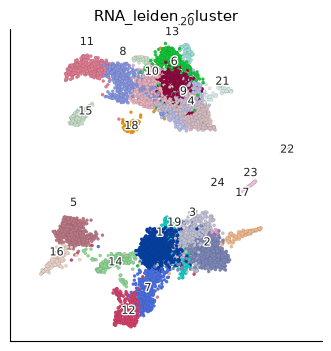

In [3]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_leiden_cluster',
)

In [4]:
ds.run_marker_search(group_key='RNA_leiden_cluster')
markers = ds.get_markers(
    group_key='RNA_leiden_cluster',
    group_id='1',
    min_score=-1,
    min_frac_exp=-1,
)
markers[['feature_name', 'score', 'frac_exp', 'p_value', 'p_value_adjusted']].head()

,feature_name,score,frac_exp,p_value,p_value_adjusted
0,RP11-1399P15.1,0.18551,0.09083,2.822936e-51,1.618483e-49
1,GPR171,0.16657,0.19358,2.470904e-77,2.460501e-75
2,SESN3,0.15856,0.23303,1.741056e-71,1.556258e-69
3,PERP,0.15463,0.09633,1.377799e-35,5.526775e-34
4,TMEM173,0.15302,0.15046,5.381645e-61,3.941447e-59


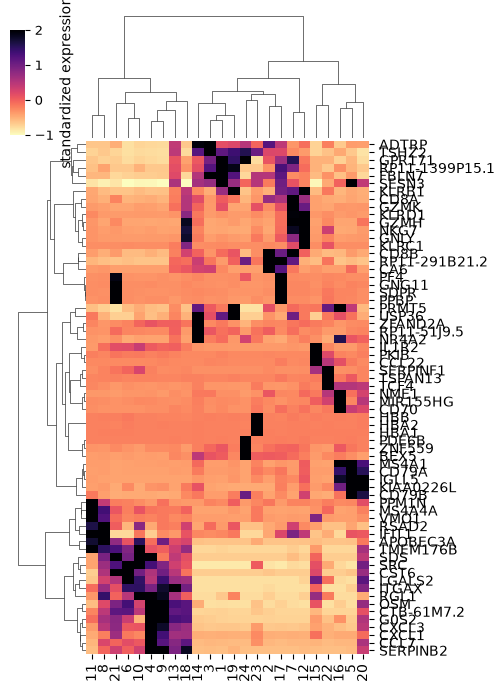

In [5]:
ds.plots.marker_heatmap(
    group_key='RNA_leiden_cluster',
    topn=3,
    figsize=(5, 7),
)

In [6]:
bulk = ds.make_bulk(
    group_key='RNA_leiden_cluster',
    aggr_type='sum',
    feature_label='name',
)
bulk.iloc[:5, :5]

,1,2,3,4,5
RP11-34P13.8,0,0,0,0,0
AL627309.1,1,0,1,0,0
RP11-206L10.2,0,1,0,0,1
RP11-206L10.9,0,0,0,0,1
FAM87B,0,0,0,0,1


In [7]:
bulk_reps = ds.make_bulk(
    group_key='RNA_leiden_cluster',
    aggr_type='sum',
    feature_label='name',
    pseudo_reps=2,
)
bulk_reps.shape

(16910, 48)

In [8]:
export_path = 'scarf_datasets/kang_pseudobulk_counts.csv'
bulk.to_csv(export_path)
print(f'Wrote {bulk.shape[0]} features x {bulk.shape[1]} groups to {export_path}')

Wrote 16910 features x 24 groups to scarf_datasets/kang_pseudobulk_counts.csv
